# 第一周作业：熟悉环境、Tensor与Numpy转换练习

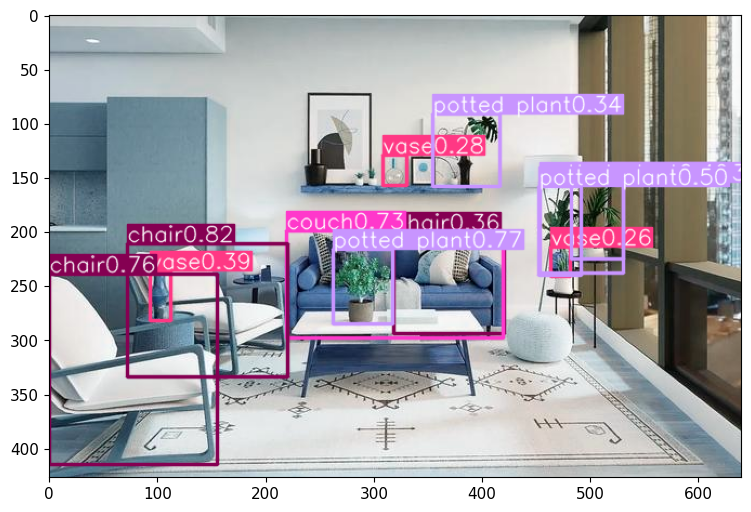

In [6]:
#1）根据自己学号建立私有独立的数据目录
import os
myid='3230105908'  ##学号##
mypath='save/'+myid
if not os.path.exists(mypath):
    os.mkdir(mypath)

In [19]:
#2）从网上选择一张图片下载、保存

import requests

url='https://n.sinaimg.cn/sinacn11/30/w1080h1350/20180609/d8d5-hcscwxc0272526.jpg'  ##替换
download=requests.get(url, allow_redirects=True)

myjpg=mypath+'/yongshi.jpg'
with open(myjpg,'wb') as fp:
    fp.write(download.content)

In [8]:
#必要时选择空闲GPU进行计算：0，1，2
#os.environ["CUDA_VISIBLE_DEVICES"]="0" 或 “1” “2”

In [20]:
# 3）用yolo对图片进行目标识别检测
from ultralytics import YOLO

# Load a pretrained YOLO11n model
model = YOLO("yolov8n.pt")
results = model.predict(myjpg)

Ultralytics YOLOv8.0.49 🚀 Python-3.7.6 torch-1.13.1+cu117 CUDA:0 (NVIDIA GeForce RTX 3090, 24124MiB)
YOLOv8n summary (fused): 168 layers, 3151904 parameters, 0 gradients, 8.7 GFLOPs

image 1/1 /data2/deeplsave/3230105908/yongshi.jpg: 640x512 5 persons, 18.8ms
Speed: 0.5ms preprocess, 18.8ms inference, 3.7ms postprocess per image at shape (1, 3, 640, 640)


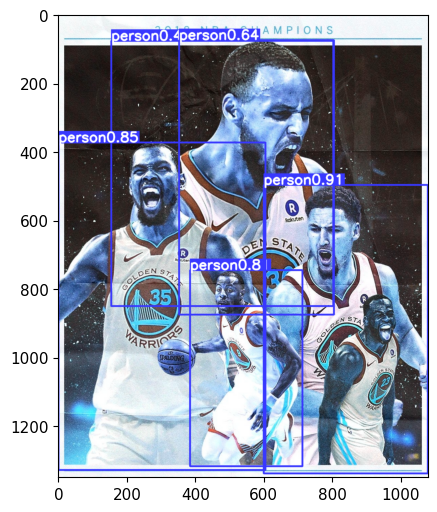

In [21]:
# 显示图片与识别结果
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(12, 6))
plt.imshow(results[0].plot())

## 按以下要求完成代码

In [22]:
# 4）提取并转换每个检测目标的信息
result = results[0]               # 第一张图片的检测结果
names = result.names              # 类别名映射字典，如 {0: 'person', 1: 'bicycle', ...}
boxes = result.boxes              # 所有检测框对象

if boxes is not None and len(boxes) > 0:
    for i in range(len(boxes)):
        # 从张量中取出数值并转为Python原生类型
        cls_id   = int(boxes.cls[i].item())            # 类别索引 → int
        conf     = float(boxes.conf[i].item())          # 置信度 → float
        xyxy     = boxes.xyxy[i].tolist()               # 坐标列表 [x1, y1, x2, y2]
        x1, y1, x2, y2 = map(int, xyxy)                # 转为整数像素坐标
        
        # 获取类别名称
        class_name = names[cls_id]
        
        # 打印
        print(f"目标{i+1}: 类别={class_name}, 确信度={conf:.4f}, "
              f"左上=({x1},{y1}), 右下=({x2},{y2})")
else:
    print("未检测到任何目标。")

目标1: 类别=person, 确信度=0.9146, 左上=(600,496), 右下=(1079,1339)
目标2: 类别=person, 确信度=0.8470, 左上=(1,372), 右下=(605,1329)
目标3: 类别=person, 确信度=0.8125, 左上=(385,745), 右下=(713,1318)
目标4: 类别=person, 确信度=0.6432, 左上=(353,73), 右下=(805,875)
目标5: 类别=person, 确信度=0.4032, 左上=(155,75), 右下=(803,850)
